In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [4]:
ghg_emissions = pd.read_excel(Path("ghg epds.xlsx"), skiprows=5)

In [5]:
ghg_emissions.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,EPD reference,GWP emissions,Functional unit,Conversion factor to 1kg,GWP 1kg (kg),Use type,Material,GWP avg,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,NaN,Concrete,CRH Concrete A/S,66.69,1 m^2,0.00267,0.178062,Wall element,Concrete,0.206481,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,CRH Concrete A/S,174.00,1 m^3,0.00135,0.234900,Leca-block,Brick,0.189735,NaN,NaN,NaN,NaN
2,NaN,NaN,Avg,NaN,NaN,NaN,NaN,0.206481,NaN,Wood,0.055150,NaN,NaN,NaN,NaN
3,NaN,NaN,Brick,Egernsund Wienerberger A/S,209.24,1 tonne,0.00100,0.209240,"walls, pillars and partitions",Steel,1.105450,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,Petersminde Teglværk,170.23,1 tonne,0.00100,0.170230,"walls, pillars and partitions",Glass,2.650200,NaN,NaN,NaN,NaN


In [10]:
Carbon_intensity = ghg_emissions[["Material", "GWP avg"]]
Carbon_intensity = Carbon_intensity.head(7)
Carbon_intensity

,Material,GWP avg
0,Concrete,0.206481
1,Brick,0.189735
2,Wood,0.055150
3,Steel,1.105450
4,Glass,2.650200
5,Aluminium,10.000500
6,Copper,7.318000


In [ ]:
Stock_TCJM = np.load('Stock_TCJM.npz', allow_pickle=True)
#check dimensions
Stock_TCJM['data'].shape, Stock_TCJM['types'].shape, Stock_TCJM['years'].shape



((501, 501, 4, 7), (4,), (501,))

In [21]:
# Extract data and GWP vector
data = Stock_TCJM['data']                          # (501, 501, 4, 7)
gwp  = Carbon_intensity["GWP avg"].values          # (7,)

# Contract over the materials axis → result shape (501, 501, 4)
carbon_stock = np.einsum('ijtm,m->ijt', data, gwp)

# carbon_stock[i, j, t] = sum over materials of (stock * GWP)
#   units: [stock units] × [kgCO₂e / kg] per cell, per building type

shapes (data, gwp, carbon_stock): (501, 501, 4, 7) (7,) (501, 501, 4)
einsum == tensordot: True
manual dot [0,0,0] = 0.0 carbon_stock = 0.0
any NaN: False
dtype: float64
min / max / mean: 0.0 11735296752.567421 26534996.275855176
total carbon stock per time index: [7.06468780e+12 3.08225755e+12 5.24325773e+12 1.12510393e+13]


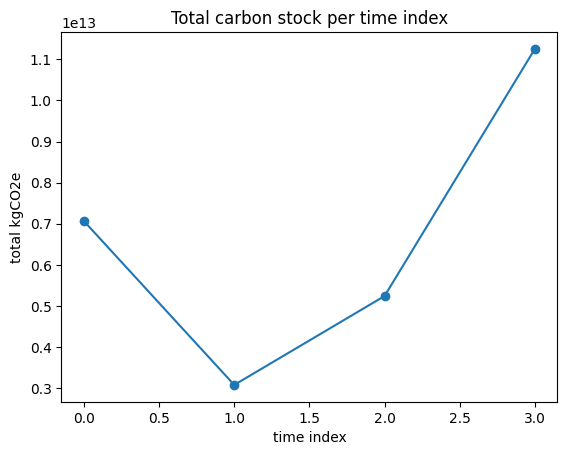

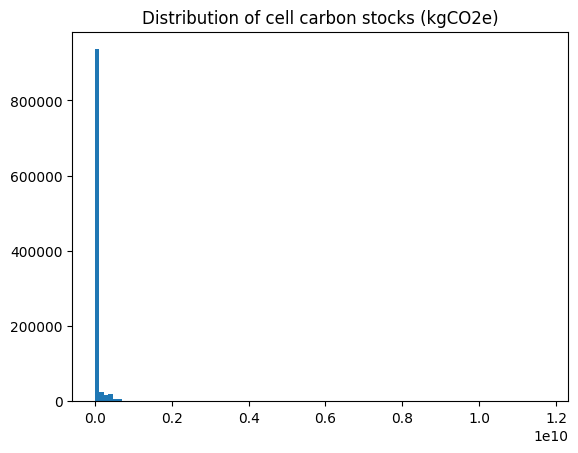

In [22]:
# ...existing code...
# Validation checks for carbon_stock
data = Stock_TCJM['data']                          # (i, j, t, m)
gwp  = Carbon_intensity["GWP avg"].values         # (m,)
print("shapes (data, gwp, carbon_stock):", data.shape, gwp.shape, carbon_stock.shape)

# basic dimension sanity
assert data.shape[3] == gwp.shape[0], "material dimension mismatch"

# compare einsum result with tensordot (alternate method)
alt = np.tensordot(data, gwp, axes=([3], [0]))    # should be (i, j, t)
print("einsum == tensordot:", np.allclose(carbon_stock, alt, equal_nan=True))

# spot-check one cell computed manually
i, j, t = 0, 0, 0
manual = np.dot(data[i, j, t, :], gwp)
print(f"manual dot [{i},{j},{t}] =", manual, "carbon_stock =", carbon_stock[i, j, t])

# NaNs, dtype, summary stats
print("any NaN:", np.isnan(carbon_stock).any())
print("dtype:", carbon_stock.dtype)
print("min / max / mean:", np.nanmin(carbon_stock), np.nanmax(carbon_stock), np.nanmean(carbon_stock))

# totals across grid (per time index)
totals_by_t = carbon_stock.sum(axis=(0, 1))   # shape (t,)
print("total carbon stock per time index:", totals_by_t)

# Optional quick plots (requires matplotlib)
import matplotlib.pyplot as plt
plt.plot(totals_by_t, marker='o'); plt.xlabel('time index'); plt.ylabel('total kgCO2e'); plt.title('Total carbon stock per time index'); plt.show()
plt.hist(carbon_stock.ravel(), bins=100); plt.title('Distribution of cell carbon stocks (kgCO2e)'); plt.show()
# ...existing code...

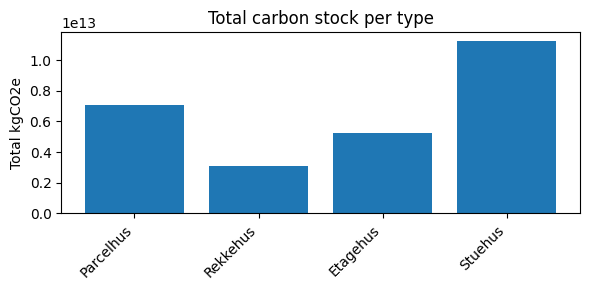

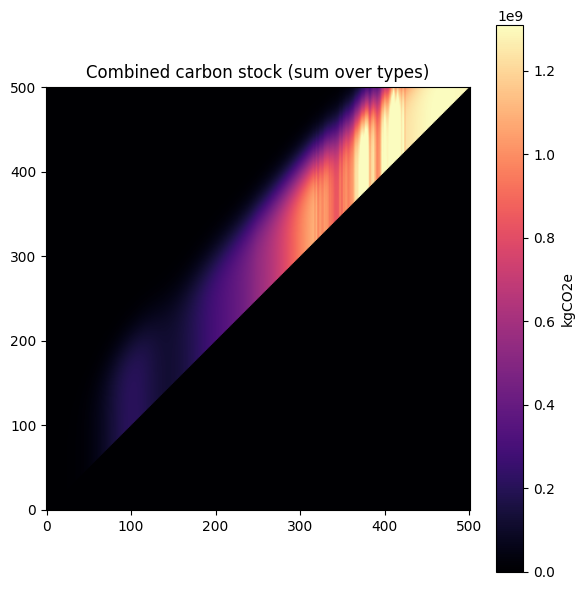

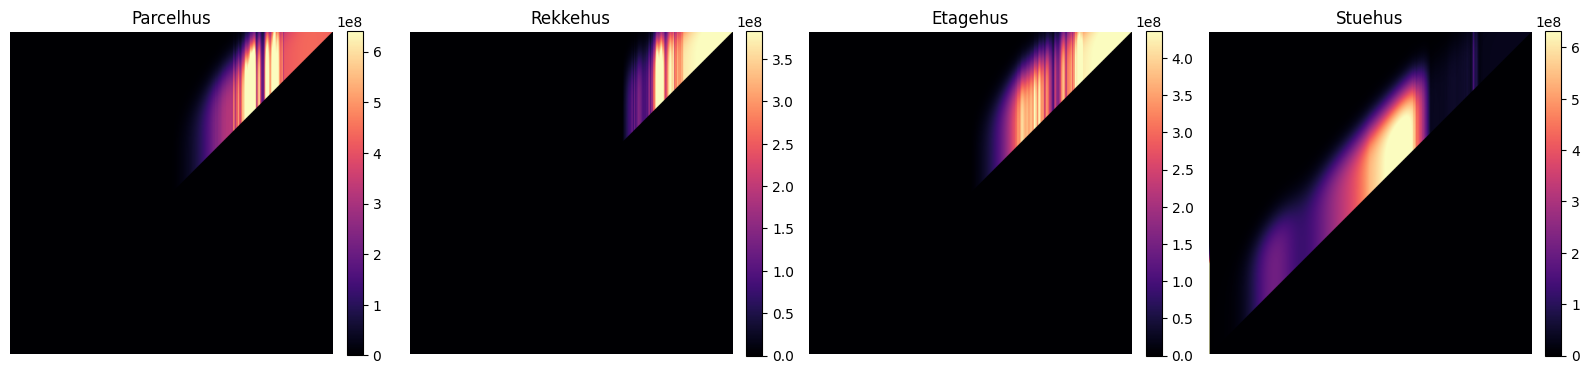

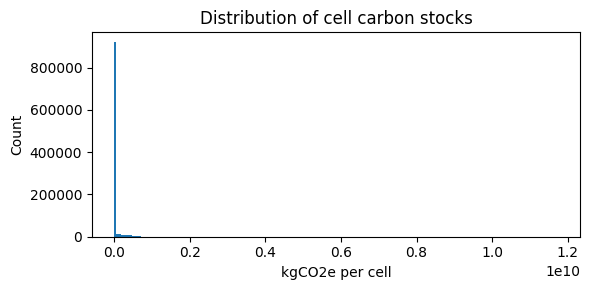

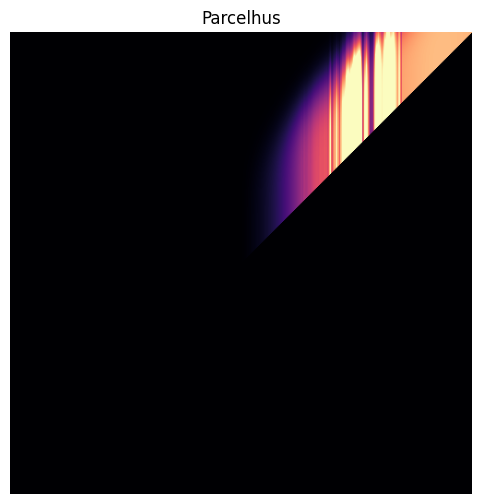

In [23]:
# ...existing code...
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np

# labels (fall back to generic names if not present)
types = Stock_TCJM.get('types', None)
labels = list(types) if types is not None else [f"type_{i}" for i in range(carbon_stock.shape[2])]

# 1) total per type (already computed earlier)
totals_by_t = carbon_stock.sum(axis=(0, 1))
plt.figure(figsize=(6,3))
plt.bar(range(len(labels)), totals_by_t)
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Total kgCO2e")
plt.title("Total carbon stock per type")
plt.tight_layout()
plt.show()

# 2) combined map (sum over types)
combined = carbon_stock.sum(axis=2)
vmin = np.nanpercentile(combined, 1)
vmax = np.nanpercentile(combined, 99)
plt.figure(figsize=(6,6))
plt.imshow(combined, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
plt.title("Combined carbon stock (sum over types)")
plt.colorbar(label='kgCO2e')
plt.tight_layout()
plt.show()

# 3) per-type maps
n = carbon_stock.shape[2]
fig, axs = plt.subplots(1, n, figsize=(4*n,4))
for t, ax in enumerate(np.atleast_1d(axs)):
    arr = carbon_stock[:, :, t]
    vmin_t = np.nanpercentile(arr, 1)
    vmax_t = np.nanpercentile(arr, 99)
    im = ax.imshow(arr, origin='lower', cmap='magma', vmin=vmin_t, vmax=vmax_t)
    ax.set_title(labels[t])
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 4) histogram / distribution
plt.figure(figsize=(6,3))
plt.hist(carbon_stock.ravel()[~np.isnan(carbon_stock.ravel())], bins=200)
plt.xlabel("kgCO2e per cell")
plt.ylabel("Count")
plt.title("Distribution of cell carbon stocks")
plt.tight_layout()
plt.show()

# 5) simple animation across types (display only; saving requires imagemagick/ffmpeg)
fig, ax = plt.subplots(figsize=(6,6))
vmin_a = np.nanpercentile(carbon_stock, 1)
vmax_a = np.nanpercentile(carbon_stock, 99)
im = ax.imshow(carbon_stock[:, :, 0], origin='lower', cmap='magma', vmin=vmin_a, vmax=vmax_a)
title = ax.set_title(labels[0])
ax.axis('off')
def update(k):
    im.set_data(carbon_stock[:, :, k])
    title.set_text(labels[k])
    return (im, title)

ani = animation.FuncAnimation(fig, update, frames=n, interval=800, blit=False)
plt.show()
# To save: ani.save('carbon_by_type.gif', writer='imagemagick')  # requires ImageMagick installed
# ...existing code...

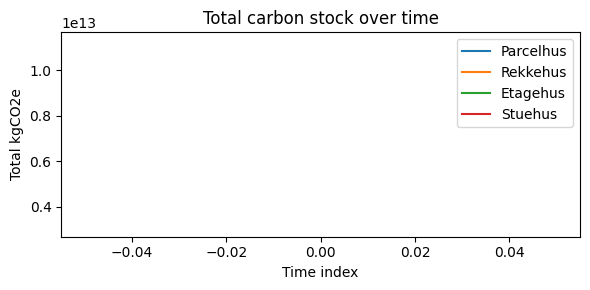

In [24]:
# Carbon stock over time
plt.figure(figsize=(6,3))
for t in range(carbon_stock.shape[2]):
    plt.plot(carbon_stock[:, :, t].sum(axis=(0, 1)), label=labels[t])
plt.xlabel("Time index")
plt.ylabel("Total kgCO2e")
plt.title("Total carbon stock over time")
plt.legend()
plt.tight_layout()
plt.show()